In [1]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
from typing import TypedDict


# ==================================================
# 1. 상태 정의
# 각 에이전트가 만든 결과를 저장하는 그릇
# ==================================================
class AgentState(TypedDict):
    query: str                  # 사용자 질문
    symptoms: str               # 추출된 증상 또는 문제
    exercise_candidates: str    # 운동 후보 리스트
    result: str                 # 최종 응답


# ==================================================
# 2. LLM 초기화
# ==================================================
llm = Ollama(model="exaone3.5:2.4b")


# ==================================================
# 3-1. 추출 에이전트
# 사용자 질문에서 증상 또는 문제 추출
# ==================================================
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 운동 추천에 필요한 증상, 문제점, 신체 상태를 추출하세요.

조건:
1. 사용자가 말한 핵심 문제만 추출하세요.
2. 결과는 쉼표로 구분된 문자열로 출력하세요.
3. 반드시 한국어로만 출력하세요.
4. 설명 문장은 쓰지 말고 추출 결과만 출력하세요.

질문: {query}
""")


def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm

    symptoms = chain.invoke({
        "query": state["query"]
    })

    return {
        **state,
        "symptoms": symptoms.strip()
    }


# ==================================================
# 3-2. 후보 에이전트
# 추출된 증상/문제를 해결할 수 있는 운동 리스트 추출
# ==================================================
matcher_prompt = PromptTemplate.from_template("""
다음 증상 또는 문제를 개선하는 데 도움이 될 수 있는 운동 리스트를 추천하세요.

증상 및 문제:
{symptoms}

조건:
1. 체력이 부족한 초보자도 할 수 있는 운동을 우선 추천하세요.
2. 체중 증가 문제를 고려해 유산소 운동과 근력 운동을 함께 포함하세요.
3. 운동 이름만 쉼표로 구분해서 출력하세요.
4. 반드시 한국어로만 출력하세요.
5. 설명 문장은 쓰지 마세요.
""")


def matcher_agent(state: AgentState):
    chain = matcher_prompt | llm

    exercises = chain.invoke({
        "symptoms": state["symptoms"]
    })

    return {
        **state,
        "exercise_candidates": exercises.strip()
    }


# ==================================================
# 3-3. 답변 생성 에이전트
# 증상과 운동 리스트를 바탕으로 개조식 답변 생성
# ==================================================
answer_prompt = PromptTemplate.from_template("""
사용자의 증상 및 문제:
{symptoms}

추천 운동 리스트:
{exercise_candidates}

위 내용을 바탕으로 사용자에게 운동 추천 답변을 작성하세요.

출력 조건:
1. 전체 답변은 반드시 한국어로 작성하세요.
2. 개조식으로 작성하세요.
3. 사용자의 문제를 먼저 정리하세요.
4. 추천 운동을 항목별로 설명하세요.
5. 각 운동이 왜 도움이 되는지 간단히 설명하세요.
6. 초보자가 시작할 수 있는 운동 방법도 함께 제시하세요.
7. 무리하지 말고 점진적으로 운동해야 한다는 주의사항을 포함하세요.
""")


def answer_agent(state: AgentState):
    chain = answer_prompt | llm

    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_candidates": state["exercise_candidates"]
    })

    return {
        **state,
        "result": answer.strip()
    }


# ==================================================
# 4. LangGraph 정의
# ==================================================
graph = StateGraph(AgentState)

graph.add_node("extractor", extractor_agent)
graph.add_node("matcher", matcher_agent)
graph.add_node("answer", answer_agent)

graph.set_entry_point("extractor")

graph.add_edge("extractor", "matcher")
graph.add_edge("matcher", "answer")
graph.add_edge("answer", END)

app = graph.compile()


# ==================================================
# 5. 그래프 구조 출력
# ==================================================
print("============================== LangGraph 구조:")
app.get_graph().print_ascii()


# ==================================================
# 6. 실행 예시
# ==================================================
query = "체력이 안좋고, 살이 계속 찌는데 어떤 운동을 할까?"

result = app.invoke({
    "query": query
})


# ==================================================
# 7. 결과 출력
# ==================================================
print("============================== 추출된 증상:")
print(result["symptoms"])

print("============================== 추천 운동 리스트:")
print(result["exercise_candidates"])

print("============================== 최종 응답:")
print(result["result"])

/var/folders/4x/fwn2w0w91c9__t6p_qlqfg080000gn/T/ipykernel_2300/1696742038.py:21: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  llm = Ollama(model="exaone3.5:2.4b")


============================== LangGraph 구조:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| extractor |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | matcher |   
 +---------+   
      *        
      *        
      *        
  +--------+   
  | answer |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   
============================== 추출된 증상:
체력 부족, 체중 증가
============================== 추천 운동 리스트:
산책, 조깅, 수영, 자전거 타기, 플랭크, 스쿼트 변형, 런지, 팔굽혀펴기, 레그 레이즈
============================== 최종 응답:
### 운동 추천 답변

#### 사용자의 주요 문제 정리:
- **체력 부족**: 일상 활동이나 가벼운 업무 수행에 어려움을 겪고 있음.
- **체중 증가**: 건강한 생활 습관 개선 필요성이 제기됨.

#### 추천 운동 리스트 및 설명:

1. **산책**
   - **설명**: 일정 시간 동안 평평한 길에서 걷기 운동으로, 쉽게 시작할 수 있는 방법입니다.
   - **도움**: 심폐 기능 향상, 체중 관리에 효과적.
   - **초보자 팁**: 처음엔 짧은 거리(약 20분)로 시작하여 점진적으로 거리와 시간을 늘려나갑니다.

2. **조깅**
   - **설명**: 걸음 수를 늘려 달리는 운동

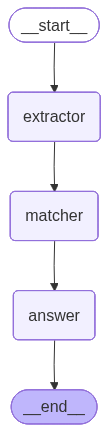

In [2]:
from IPython.display import Image, display 
display(Image(app.get_graph().draw_mermaid_png()))